# CelebA Milestone 1: Training and Validation

**Selected identity IDs:** 7007, 2970, 2336, 7, and 4428.

These five labeled folders are available to the team. The cell below checks
that each identity has at least 20 images. It then uses the same number of
images from each identity to keep the classes balanced. Review the sample
photos before claiming that the subset is visually diverse.

Change `DATA_DIR` if your path differs.
Select a GPU runtime in Colab before running the notebook.


In [29]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from IPython.display import display
from google.colab import drive
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/02_project01_milestone1")
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/02_project01_milestone1/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IDS = ["7007", "2970", "2336", "7", "4428"]
SEED = 47
MIN_IMAGES = 20
EPOCHS = 30
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## 1. Check images and create a per-identity split

Use 70% for training, 15% for validation, and 15% for a held-out test set.
The test images are listed in the saved split file but are not used below.


,identity,images
0,7007,24
1,2970,25
2,2336,25
3,7,24
4,4428,23


split,test,train,val
identity,,,
2336,3,17,3
2970,3,17,3
4428,3,17,3
7,3,17,3
7007,3,17,3


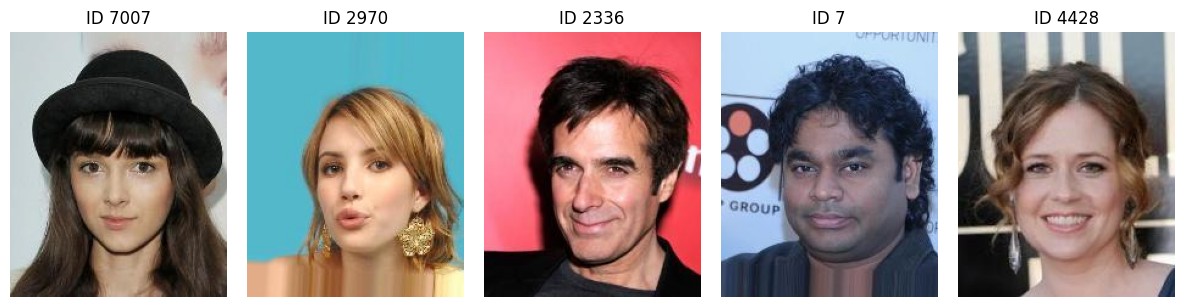

In [30]:
image_files = {}
for identity in IDS:
    folder = DATA_DIR / identity
    if not folder.is_dir():
        raise FileNotFoundError(f"Identity folder not found: {folder}")
    image_files[identity] = sorted(
        p for p in folder.rglob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )

counts = pd.DataFrame({"identity": IDS, "images": [len(image_files[i]) for i in IDS]})
display(counts)
if counts["images"].min() < MIN_IMAGES:
    raise ValueError("Every identity needs at least 20 images. Check the counts above.")

images_per_identity = int(counts["images"].min())
n_val = round(images_per_identity * 0.15)
n_test = round(images_per_identity * 0.15)
n_train = images_per_identity - n_val - n_test

rows = []
for identity in IDS:
    paths = image_files[identity].copy()
    random.Random(SEED + int(identity)).shuffle(paths)
    paths = paths[:images_per_identity]
    for split, selected in (
        ("train", paths[:n_train]),
        ("val", paths[n_train:n_train + n_val]),
        ("test", paths[n_train + n_val:]),
    ):
        for path in selected:
            rows.append({"identity": identity, "split": split,
                         "file": path.relative_to(DATA_DIR).as_posix()})

manifest = pd.DataFrame(rows)
display(manifest.groupby(["identity", "split"]).size().unstack(fill_value=0))

fig, axes = plt.subplots(1, len(IDS), figsize=(12, 3))
for ax, identity in zip(axes, IDS):
    sample_file = manifest[(manifest.identity == identity) &
                           (manifest.split == "train")].iloc[0]["file"]
    with Image.open(DATA_DIR / sample_file) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(f"ID {identity}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Preprocessing

Training images get a random crop and horizontal flip. Validation images get
a fixed resize and center crop. All images use RGB, 224 × 224 pixels, and
ImageNet normalization (also required by the pretrained model).


In [31]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(mean, std),
])
val_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean, std),
])


class Faces(Dataset):
    def __init__(self, split, transform):
        self.rows = manifest[manifest.split == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        with Image.open(DATA_DIR / row["file"]) as image:
            x = self.transform(image.convert("RGB"))
        return x, IDS.index(row["identity"])


train_data = Faces("train", train_transform)
val_data = Faces("val", val_transform)


## 3. Models

| Model | Architecture | Depth and channels | Regularization / initialization |
|---|---|---|---|
| **Model 1** | Small custom CNN | 2 convolution layers: 32, 64 channels | Dropout 0.25; random weights |
| **Model 2** | Deeper custom CNN | 4 convolution layers: 32, 64, 128, 256 channels | Dropout 0.35; random weights |
| **Model 3** | ResNet18 transfer learning | 18-layer backbone; stage channels 64, 128, 256, 512 | ImageNet weights; frozen backbone; train a new 5-class head |

All three models predict one of the same five identity IDs.


In [32]:
class CustomCNN(nn.Module):
    def __init__(self, channels, dropout):
        super().__init__()
        layers = []
        previous = 3
        for width in channels:
            layers += [nn.Conv2d(previous, width, 3, padding=1),
                       nn.ReLU(), nn.MaxPool2d(2)]
            previous = width
        self.network = nn.Sequential(
            *layers, nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(previous, len(IDS)),
        )

    def forward(self, x):
        return self.network(x)


def make_model(number):
    if number == 1:
        return CustomCNN([32, 64], 0.25)
    if number == 2:
        return CustomCNN([32, 64, 128, 256], 0.35)
    if number == 3:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for parameter in model.parameters():
            parameter.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, len(IDS))
        return model
    raise ValueError("Unknown model number")


## 4. Train and validate

Each model uses the same split, batch size, and number of epochs. Save the
checkpoint with the lowest validation loss. The accuracy below is **validation
accuracy**, not test accuracy. A teammate can use `split.csv` for the final
held-out evaluation.


In [33]:
def run_epoch(model, loader, optimizer=None, frozen_backbone=False):
    training = optimizer is not None
    model.train(training)
    if training and frozen_backbone:
        model.eval()  # Keep ResNet's pretrained BatchNorm statistics fixed.
    loss_sum = correct = total = 0
    with torch.set_grad_enabled(training):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(images)
            loss = nn.functional.cross_entropy(logits, targets)
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * len(targets)
            correct += (logits.argmax(1) == targets).sum().item()
            total += len(targets)
    return loss_sum / total, correct / total


results = []
for number in (1, 2, 3):
    torch.manual_seed(SEED)
    model = make_model(number).to(DEVICE)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
    optimizer = torch.optim.Adam(
        (p for p in model.parameters() if p.requires_grad), lr=0.001
    )
    best_loss = float("inf")
    history = []
    start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_epoch(
            model, train_loader, optimizer, frozen_backbone=(number == 3)
        )
        val_loss, val_acc = run_epoch(model, val_loader)
        history.append({"epoch": epoch, "train_loss": train_loss,
                        "train_accuracy": train_acc, "val_loss": val_loss,
                        "val_accuracy": val_acc})
        print(f"Model {number}, epoch {epoch}: train {train_acc:.1%}, val {val_acc:.1%}")
        if val_loss < best_loss:
            best_loss = val_loss
            best_acc = val_acc
            best_epoch = epoch
            torch.save({"state_dict": model.state_dict(), "ids": IDS,
                        "model_number": number}, OUTPUT_DIR / f"model_{number}.pt")

    pd.DataFrame(history).to_csv(OUTPUT_DIR / f"model_{number}_history.csv", index=False)
    results.append({"model": f"Model {number}",
                    "parameters": sum(p.numel() for p in model.parameters()),
                    "best_epoch": best_epoch, "validation_accuracy": best_acc,
                    "training_seconds": round(time.perf_counter() - start, 1)})

summary = pd.DataFrame(results)

display(summary)


Model 1, epoch 1: train 17.6%, val 26.7%
Model 1, epoch 2: train 17.6%, val 13.3%
Model 1, epoch 3: train 18.8%, val 13.3%
Model 1, epoch 4: train 21.2%, val 20.0%
Model 1, epoch 5: train 25.9%, val 13.3%
Model 1, epoch 6: train 24.7%, val 20.0%
Model 1, epoch 7: train 28.2%, val 20.0%
Model 1, epoch 8: train 30.6%, val 13.3%
Model 1, epoch 9: train 37.6%, val 13.3%
Model 1, epoch 10: train 35.3%, val 13.3%
Model 1, epoch 11: train 30.6%, val 13.3%
Model 1, epoch 12: train 29.4%, val 20.0%
Model 1, epoch 13: train 37.6%, val 13.3%
Model 1, epoch 14: train 41.2%, val 26.7%
Model 1, epoch 15: train 36.5%, val 33.3%
Model 1, epoch 16: train 42.4%, val 26.7%
Model 1, epoch 17: train 29.4%, val 33.3%
Model 1, epoch 18: train 35.3%, val 20.0%
Model 1, epoch 19: train 30.6%, val 20.0%
Model 1, epoch 20: train 38.8%, val 26.7%
Model 1, epoch 21: train 37.6%, val 26.7%
Model 1, epoch 22: train 40.0%, val 26.7%
Model 1, epoch 23: train 41.2%, val 20.0%
Model 1, epoch 24: train 34.1%, val 20.0%
M

,model,parameters,best_epoch,validation_accuracy,training_seconds
0,Model 1,19717,29,0.333333,18.9
1,Model 2,389701,28,0.533333,21.7
2,Model 3,11179077,30,0.800000,21.9
